Loaded 3,801 rows | Fox%: 52.62%
Temporal   — Train: 3,058 | Test: 743
Stratified — Train: 3,040 | Test: 761
Fitting LR (time_split)...
  Style + LR — time_split: 0.7362
Fitting RF (time_split)...
  Style + RF — time_split: 0.6797
Fitting SVM (time_split)...
  Style + SVM — time_split: 0.7160
Fitting XGB (time_split)...


/Users/rohankrishnan/Documents/GitHub/cis-5190-news/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:21:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Style + XGB — time_split: 0.7376
Fitting LR (stratified)...
  Style + LR — stratified: 0.7267
Fitting RF (stratified)...
  Style + RF — stratified: 0.6833
Fitting SVM (stratified)...
  Style + SVM — stratified: 0.7306
Fitting XGB (stratified)...


/Users/rohankrishnan/Documents/GitHub/cis-5190-news/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:21:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Style + XGB — stratified: 0.7214


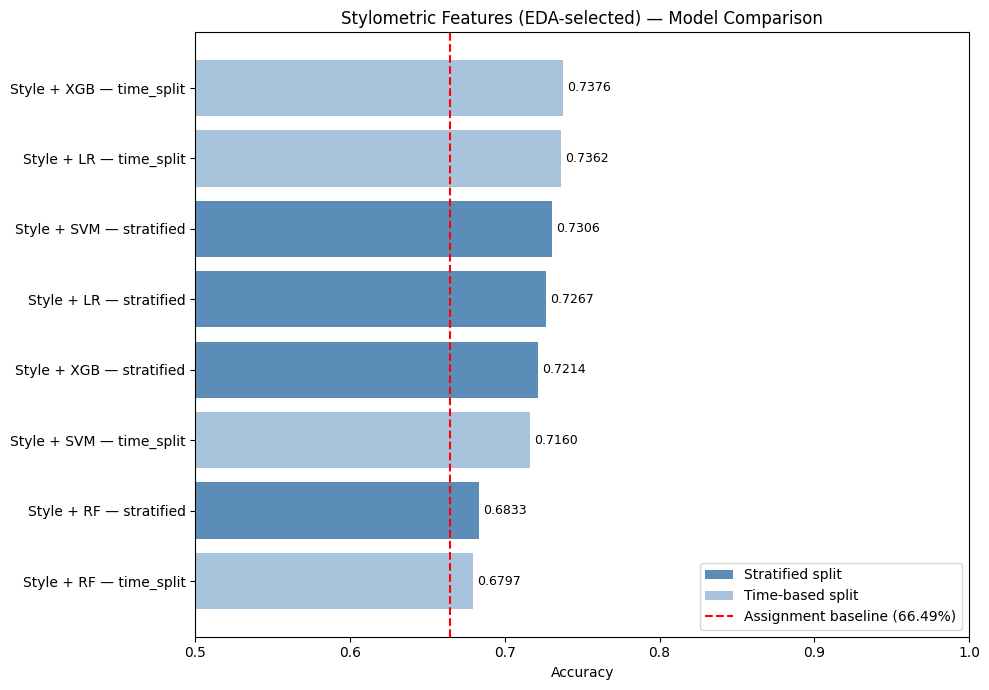

Plot saved.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# ── LOAD PRECOMPUTED FEATURES ────────────────────────────────────────────────
# No spaCy, no VADER — clean memory environment for SVM
feature_df = pd.read_csv("../data/processed/style_features.csv", index_col=0)
feature_df["datetime_posted"] = pd.to_datetime(
    feature_df["datetime_posted"], utc=True, format="mixed"
)

print(f"Loaded {len(feature_df):,} rows | Fox%: {feature_df['is_fox'].mean():.2%}")

FEATURE_COLS = [
    "has_colon", "starts_with_number", "n_words", "char_count",
    "person_to_ent_ratio", "has_question", "allcaps_word_count"
]

# ── SPLITS ───────────────────────────────────────────────────────────────────

# -- Temporal --
df_dated   = feature_df.dropna(subset=["datetime_posted"]).sort_values("datetime_posted")
df_undated = feature_df[feature_df["datetime_posted"].isna()]
split_idx  = int(len(df_dated) * 0.8)
train_dated, test_t = df_dated.iloc[:split_idx], df_dated.iloc[split_idx:]
train_t = pd.concat([train_dated, df_undated], ignore_index=False)

X_train_t = train_t[FEATURE_COLS]
X_test_t  = test_t[FEATURE_COLS]
y_train_t = train_t["is_fox"]
y_test_t  = test_t["is_fox"]

# -- Stratified --
train_s, test_s = train_test_split(
    feature_df, test_size=0.2, random_state=42, stratify=feature_df["is_fox"]
)
X_train_s = train_s[FEATURE_COLS]
X_test_s  = test_s[FEATURE_COLS]
y_train_s = train_s["is_fox"]
y_test_s  = test_s["is_fox"]

print(f"Temporal   — Train: {len(X_train_t):,} | Test: {len(X_test_t):,}")
print(f"Stratified — Train: {len(X_train_s):,} | Test: {len(X_test_s):,}")

# ── MODELS ───────────────────────────────────────────────────────────────────
models = {
    "LR":  LogisticRegression(max_iter=1000, random_state=42),
    "RF":  RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "XGB": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
    ),
}

results = []

for split_name, X_tr, X_te, y_tr, y_te in [
    ("time_split", X_train_t, X_test_t, y_train_t, y_test_t),
    ("stratified", X_train_s, X_test_s, y_train_s, y_test_s),
]:
    scaler      = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    for model_name, model in models.items():
        print(f"Fitting {model_name} ({split_name})...")
        model.fit(X_tr_scaled, y_tr)
        acc   = accuracy_score(y_te, model.predict(X_te_scaled))
        label = f"Style + {model_name} — {split_name}"
        results.append({"label": label, "accuracy": acc, "split": split_name})
        print(f"  {label}: {acc:.4f}")

# ── PLOT ─────────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values("accuracy")
colors = ["#5b8db8" if s == "stratified" else "#a8c4dc" for s in results_df["split"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(results_df["label"], results_df["accuracy"], color=colors)
ax.axvline(0.6649, color="red", linestyle="--", label="Assignment baseline (66.49%)")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("Accuracy")
ax.set_title("Stylometric Features (EDA-selected) — Model Comparison")

legend_elements = [
    Patch(facecolor="#5b8db8", label="Stratified split"),
    Patch(facecolor="#a8c4dc", label="Time-based split"),
    plt.Line2D([0], [0], color="red", linestyle="--", label="Assignment baseline (66.49%)"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
# plt.savefig("stylometric_eda_selected_model_comparison.png", dpi=150)
plt.show()
print("Plot saved.")